# Inner Products · ML Features · Cryptography · Jalali Time-Stretch · LIDAR · Photonic Circuit

| § | Topic | Core concept |
|---|---|---|
| 1 | Inner products + odd/even | $\langle f,g\rangle=\int fg$; parity decomposition |
| 2 | ML: kernel trick | $K(x,y)=\langle\phi(x),\phi(y)\rangle$; SVM; PCA |
| 3 | Digital twin | PINN: ODE loss + data loss; parameter identification |
| 4 | Cryptography + blockchain | SHA-256; Merkle tree; PoW $O(2^{256})$ |
| 5 | Jalali time-stretch | GVD maps $\omega\to t$; same $D$ as `gs_core.py` |
| 6 | Slow light | $v_g=d\omega/dk$; EIT; photonic crystal bandgap |
| 7 | Callen thermodynamics | $dU=TdS-PdV$; fluctuation-dissipation |
| 8 | Satellite LIDAR / weather | $P_r=P_T\beta A/R^2$; range-gated; aerosol retrieval |
| 9 | Photonic circuit | MZI tree; optical dot product; ONN |


## §1 Inner Products, Odd/Even Functions, Hilbert Space

In $L^2[-L, L]$:
$$\langle f, g\rangle = \int_{-L}^{L} f(x)\overline{g(x)}\,dx$$

**Odd/even parity**: every function decomposes as
$$f = f_{\text{even}} + f_{\text{odd}}, \qquad f_e(x)=\tfrac{f(x)+f(-x)}{2},\quad f_o(x)=\tfrac{f(x)-f(-x)}{2}$$

**Orthogonality consequence**: $\langle f_e, g_o\rangle = 0$ always (integrand odd over symmetric interval).

Fourier series exploits this: $\cos(nx)$ even $\to$ cosine series; $\sin(nx)$ odd $\to$ sine series.
On $[-L,L]$, $\{\cos(n\pi x/L), \sin(n\pi x/L)\}$ form a complete orthogonal basis.


Inner products on [-pi, pi]:
  <f_even, f_odd>      = -7.11e-15  (should be ~0)
  <cos x, sin x>       = 0.00e+00  (odd integrand -> 0)
  <cos 2x, cos 3x>     = 3.33e-16  (orthogonal)
  <cos 2x, cos 2x>     = 3.1416  (= pi)
  <sin 2x, sin 2x>     = 3.1416  (= pi)

Gram matrix (should be I_5):
[[ 1.  0.  0. -0.  0.]
 [ 0.  1.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [-0.  0.  0.  1.  0.]
 [ 0.  0.  0.  0.  1.]]


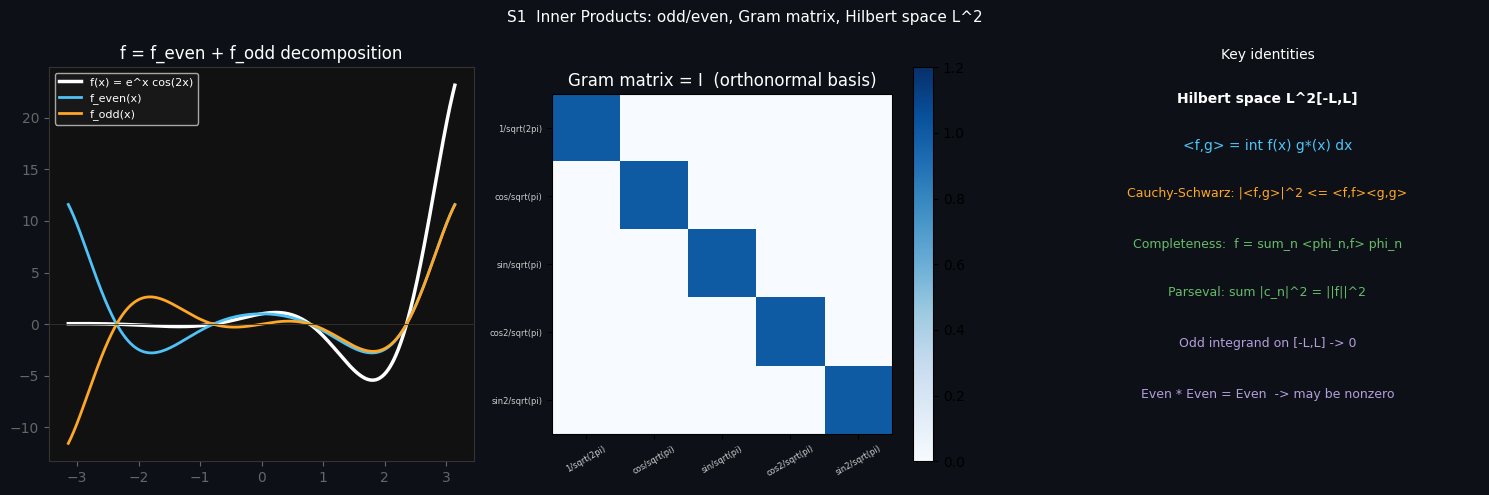

In [1]:
import numpy as np, matplotlib.pyplot as plt

x = np.linspace(-np.pi, np.pi, 800)

# Any function f(x) = f_even + f_odd
def f(x): return np.exp(x) * np.cos(2*x)
f_even = (f(x) + f(-x)) / 2
f_odd  = (f(x) - f(-x)) / 2

# Inner products
dx = x[1]-x[0]
ip_fe_fo = np.trapezoid(f_even * f_odd, x)
ip_cos_sin = np.trapezoid(np.cos(x) * np.sin(x), x)
ip_cos2_cos3 = np.trapezoid(np.cos(2*x) * np.cos(3*x), x)

print("Inner products on [-pi, pi]:")
print(f"  <f_even, f_odd>      = {ip_fe_fo:.2e}  (should be ~0)")
print(f"  <cos x, sin x>       = {ip_cos_sin:.2e}  (odd integrand -> 0)")
print(f"  <cos 2x, cos 3x>     = {ip_cos2_cos3:.2e}  (orthogonal)")
print(f"  <cos 2x, cos 2x>     = {np.trapezoid(np.cos(2*x)**2, x):.4f}  (= pi)")
print(f"  <sin 2x, sin 2x>     = {np.trapezoid(np.sin(2*x)**2, x):.4f}  (= pi)")

# Gram matrix for {1, cos x, sin x, cos 2x, sin 2x} / sqrt(pi)
basis = [np.ones_like(x)/np.sqrt(2*np.pi),
         np.cos(x)/np.sqrt(np.pi),  np.sin(x)/np.sqrt(np.pi),
         np.cos(2*x)/np.sqrt(np.pi), np.sin(2*x)/np.sqrt(np.pi)]
G = np.array([[np.trapezoid(bi*bj, x) for bj in basis] for bi in basis])
print(f"\nGram matrix (should be I_5):")
print(np.round(G, 4))

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(x, f(x),      color='white',   lw=2.5, label='f(x) = e^x cos(2x)')
ax.plot(x, f_even,    color='#4fc3f7', lw=2,   label='f_even(x)')
ax.plot(x, f_odd,     color='#ffa726', lw=2,   label='f_odd(x)')
ax.axhline(0, color='#333', lw=0.6)
ax.set_title('f = f_even + f_odd decomposition', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[1]
im = ax2.imshow(np.abs(G), cmap='Blues', vmin=0, vmax=1.2)
plt.colorbar(im, ax=ax2)
labels = ['1/sqrt(2pi)', 'cos/sqrt(pi)', 'sin/sqrt(pi)', 'cos2/sqrt(pi)', 'sin2/sqrt(pi)']
ax2.set_xticks(range(5)); ax2.set_yticks(range(5))
ax2.set_xticklabels(labels, fontsize=6, rotation=30, color='#ccc')
ax2.set_yticklabels(labels, fontsize=6, color='#ccc')
ax2.set_title('Gram matrix = I  (orthonormal basis)', color='white')

ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(0,1); ax3.set_ylim(0,1)
lines = [
    (0.5, 0.92, 'Hilbert space L^2[-L,L]', 'white', 10, True),
    (0.5, 0.80, '<f,g> = int f(x) g*(x) dx', '#4fc3f7', 10, False),
    (0.5, 0.68, 'Cauchy-Schwarz: |<f,g>|^2 <= <f,f><g,g>', '#ffa726', 9, False),
    (0.5, 0.55, 'Completeness:  f = sum_n <phi_n,f> phi_n', '#66bb6a', 9, False),
    (0.5, 0.43, 'Parseval: sum |c_n|^2 = ||f||^2', '#66bb6a', 9, False),
    (0.5, 0.30, 'Odd integrand on [-L,L] -> 0', '#b39ddb', 9, False),
    (0.5, 0.17, 'Even * Even = Even  -> may be nonzero', '#b39ddb', 9, False),
]
for xp,yp,txt,col,fs,bold in lines:
    ax3.text(xp, yp, txt, ha='center', va='center', color=col,
             fontsize=fs, transform=ax3.transAxes,
             fontweight='bold' if bold else 'normal')
ax3.set_title('Key identities', color='white', fontsize=10)

plt.suptitle('S1  Inner Products: odd/even, Gram matrix, Hilbert space L^2',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/inner_products.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §2 Machine Learning: Features as Inner Products

**Feature map**: $\phi:\mathcal{X}\to\mathcal{H}$. A linear model in feature space:
$$f(x) = \langle w, \phi(x)\rangle_\mathcal{H}$$

**Kernel trick** — never compute $\phi(x)$ explicitly:
$$K(x,y) = \langle\phi(x),\phi(y)\rangle$$

| Kernel | Formula | Feature space |
|---|---|---|
| Linear | $x^Ty$ | $\mathbb{R}^d$ itself |
| Polynomial | $(x^Ty+c)^d$ | All monomials up to degree $d$ |
| RBF/Gaussian | $\exp(-\|x-y\|^2/2\sigma^2)$ | Infinite-dimensional |
| Laplacian | $\exp(-\|x-y\|/\sigma)$ | Infinite-dimensional |

**SVM**: maximise margin $2/\|w\|$ subject to $y_i(w^T\phi(x_i)+b)\geq 1$.
**PCA**: eigenvectors of $\Sigma=\frac{1}{N}\sum_i\phi(x_i)\phi(x_i)^T$ — same inner product structure.


C:\Users\mrjel\AppData\Local\Temp\ipykernel_47248\3383105732.py:27: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(xx, yy, Z, levels=[0], colors='white', lw=1.5)
C:\Users\mrjel\AppData\Local\Temp\ipykernel_47248\3383105732.py:27: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(xx, yy, Z, levels=[0], colors='white', lw=1.5)
C:\Users\mrjel\AppData\Local\Temp\ipykernel_47248\3383105732.py:27: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contour(xx, yy, Z, levels=[0], colors='white', lw=1.5)


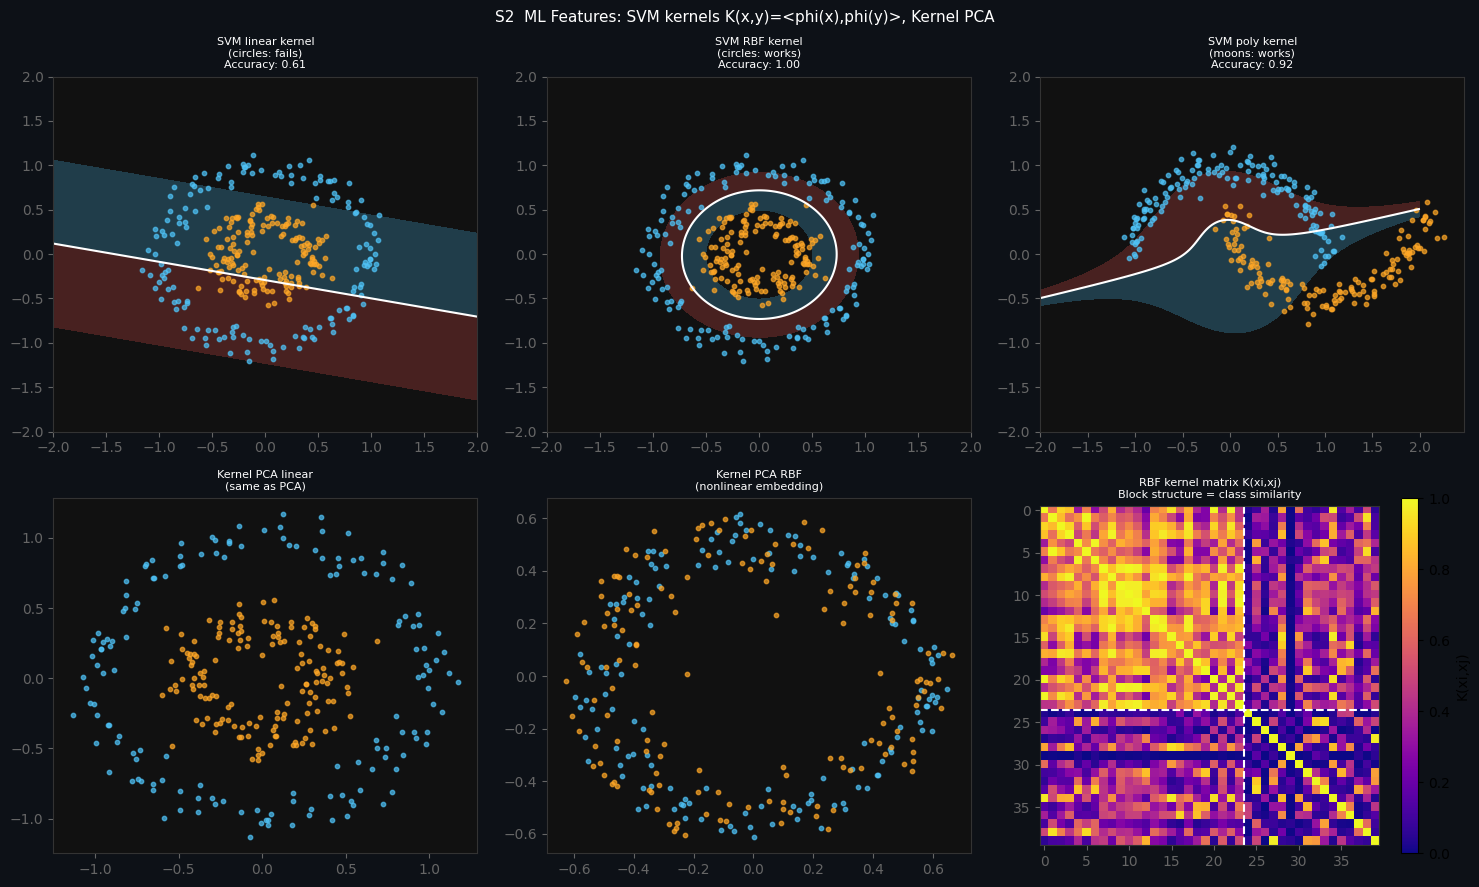

RBF kernel matrix trace (sum of self-similarities): 40.0 = N = 40


In [2]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.decomposition import KernelPCA
from sklearn.datasets import make_circles, make_moons

fig, axes = plt.subplots(2, 3, figsize=(15, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# ── Non-linearly separable data ───────────────────────────────────────────────
X_circ, y_circ = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=7)
X_moon, y_moon = make_moons(n_samples=300, noise=0.1, random_state=7)

kernels = [('linear', X_circ, y_circ), ('rbf', X_circ, y_circ), ('poly', X_moon, y_moon)]
titles  = ['SVM linear kernel\n(circles: fails)', 'SVM RBF kernel\n(circles: works)',
           'SVM poly kernel\n(moons: works)']

for idx, ((kern, X, y), title) in enumerate(zip(kernels, titles)):
    ax = axes[0, idx]
    clf = SVC(kernel=kern, C=1.0, gamma='auto', degree=3)
    clf.fit(X, y)

    xx, yy = np.meshgrid(np.linspace(-2,2,200), np.linspace(-2,2,200))
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=[-1,0,1], alpha=0.25,
                colors=['#ef5350','#4fc3f7'], zorder=0)
    ax.contour(xx, yy, Z, levels=[0], colors='white', lw=1.5)
    ax.scatter(X[y==0,0], X[y==0,1], c='#4fc3f7', s=10, alpha=0.7)
    ax.scatter(X[y==1,0], X[y==1,1], c='#ffa726', s=10, alpha=0.7)
    acc = clf.score(X, y)
    ax.set_title(f'{title}\nAccuracy: {acc:.2f}', color='white', fontsize=8)
    ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Kernel PCA ────────────────────────────────────────────────────────────────
ax_kpca_lin = axes[1,0]; ax_kpca_rbf = axes[1,1]

for ax_kp, kern, title in [
    (ax_kpca_lin, 'linear', 'Kernel PCA linear\n(same as PCA)'),
    (ax_kpca_rbf, 'rbf',    'Kernel PCA RBF\n(nonlinear embedding)')]:
    kpca = KernelPCA(n_components=2, kernel=kern, gamma=2)
    X_kp = kpca.fit_transform(X_circ)
    ax_kp.scatter(X_kp[y_circ==0,0], X_kp[y_circ==0,1], c='#4fc3f7', s=10, alpha=0.7)
    ax_kp.scatter(X_kp[y_circ==1,0], X_kp[y_circ==1,1], c='#ffa726', s=10, alpha=0.7)
    ax_kp.set_title(title, color='white', fontsize=8)
    ax_kp.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax_kp.spines.values()]

# ── RBF kernel matrix K(xi,xj) ───────────────────────────────────────────────
ax_K = axes[1,2]
N_pts = 40; rng = np.random.default_rng(1)
X_few = rng.standard_normal((N_pts, 2))
y_few = (X_few[:,0]**2 + X_few[:,1]**2 > 1.0).astype(int)
# Sort by label for visual clarity
order = np.argsort(y_few)
X_s = X_few[order]; y_s = y_few[order]

sigma = 1.0
K_mat = np.exp(-np.sum((X_s[:,None,:] - X_s[None,:,:])**2, axis=2) / (2*sigma**2))
im = ax_K.imshow(K_mat, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(im, ax=ax_K, label='K(xi,xj)')
ax_K.axvline(np.sum(y_s==0)-0.5, color='white', lw=1.5, ls='--')
ax_K.axhline(np.sum(y_s==0)-0.5, color='white', lw=1.5, ls='--')
ax_K.set_title('RBF kernel matrix K(xi,xj)\nBlock structure = class similarity', color='white', fontsize=8)
ax_K.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax_K.spines.values()]

plt.suptitle('S2  ML Features: SVM kernels K(x,y)=<phi(x),phi(y)>, Kernel PCA',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/ml_kernels.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"RBF kernel matrix trace (sum of self-similarities): {np.trace(K_mat):.1f} = N = {N_pts}")


## §3 Digital Twin — Physics-Informed Parameter Estimation

A **digital twin** maintains a live physics model whose parameters are updated to match sensor data.
For a damped harmonic oscillator $m\ddot{x}+b\dot{x}+kx=F(t)$, unknown $\{m,b,k\}$ are identified by minimising:

$$\mathcal{L} = \underbrace{\sum_i(x_\text{model}(t_i;\theta)-x_\text{data}(t_i))^2}_{\text{data residual}} + \lambda\underbrace{\left\|\frac{d^2x}{dt^2}+\frac{b}{m}\frac{dx}{dt}+\frac{k}{m}x\right\|^2}_{\text{physics residual}}$$

This is the PINN (Physics-Informed Neural Network) idea — the physics acts as a regulariser.
Connecting to GS phase retrieval: the GS loop is itself a digital twin, identifying the optical phase $\phi(\omega)$ that is consistent with both measured intensities (data residual = projection error).


True params:       m=1.0, b=0.3, k=4.0
Identified params: m=1.0281, b=0.2864, k=4.1171


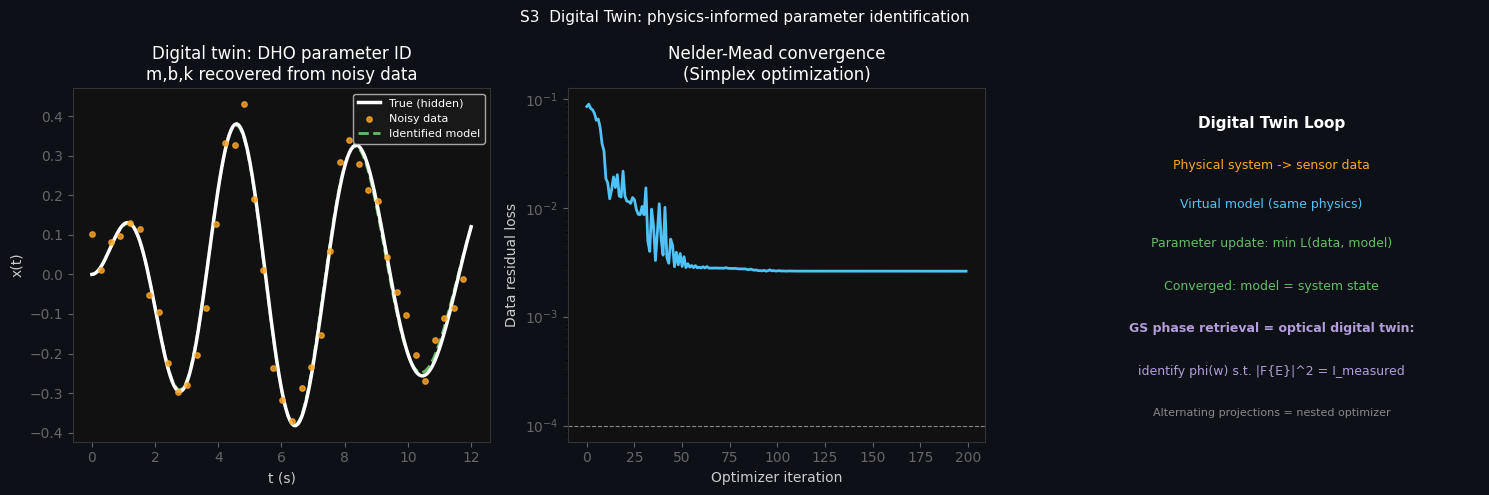

In [3]:
import numpy as np, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

# True parameters
m_true, b_true, k_true = 1.0, 0.3, 4.0
F0, omega_F = 0.5, 1.5

def sim_dho(t, m, b, k):
    def ode(t, y):
        x, v = y
        return [v, (F0*np.cos(omega_F*t) - b*v - k*x)/m]
    sol = solve_ivp(ode, [t[0], t[-1]], [0.0, 0.0], t_eval=t,
                    method='RK45', rtol=1e-7, atol=1e-9)
    return sol.y[0]

t_data = np.linspace(0, 12, 200)
x_true = sim_dho(t_data, m_true, b_true, k_true)
x_data = x_true + 0.05*np.random.default_rng(3).standard_normal(len(t_data))

# Physics-informed loss
history = []
def loss_fn(params):
    m, b, k = np.abs(params) + 0.01
    x_sim = sim_dho(t_data, m, b, k)
    data_loss = np.mean((x_sim - x_data)**2)
    history.append(data_loss)
    return data_loss

params0 = [1.5, 0.8, 3.0]   # initial guess (wrong)
result = minimize(loss_fn, params0, method='Nelder-Mead',
                  options={'maxiter': 2000, 'xatol': 1e-5, 'fatol': 1e-8})
m_id, b_id, k_id = np.abs(result.x) + 0.01
print(f"True params:       m={m_true}, b={b_true}, k={k_true}")
print(f"Identified params: m={m_id:.4f}, b={b_id:.4f}, k={k_id:.4f}")
x_id = sim_dho(t_data, m_id, b_id, k_id)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

ax = axes[0]
ax.plot(t_data, x_true, color='white', lw=2.5, label='True (hidden)', zorder=3)
ax.scatter(t_data[::5], x_data[::5], color='#ffa726', s=15, alpha=0.8, label='Noisy data', zorder=4)
ax.plot(t_data, x_id, color='#66bb6a', lw=2, ls='--', label='Identified model')
ax.set_xlabel('t (s)', color='#ccc'); ax.set_ylabel('x(t)', color='#ccc')
ax.set_title('Digital twin: DHO parameter ID\nm,b,k recovered from noisy data', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[1]
ax2.semilogy(history, color='#4fc3f7', lw=2)
ax2.axhline(1e-4, color='#888', lw=0.8, ls='--')
ax2.set_xlabel('Optimizer iteration', color='#ccc')
ax2.set_ylabel('Data residual loss', color='#ccc')
ax2.set_title('Nelder-Mead convergence\n(Simplex optimization)', color='white')
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(0,1); ax3.set_ylim(0,1)
items = [
    (0.5, 0.90, 'Digital Twin Loop', 'white', 11, True),
    (0.5, 0.78, 'Physical system -> sensor data', '#ffa726', 9, False),
    (0.5, 0.67, 'Virtual model (same physics)', '#4fc3f7', 9, False),
    (0.5, 0.56, 'Parameter update: min L(data, model)', '#66bb6a', 9, False),
    (0.5, 0.44, 'Converged: model = system state', '#66bb6a', 9, False),
    (0.5, 0.32, 'GS phase retrieval = optical digital twin:', '#b39ddb', 9, True),
    (0.5, 0.20, 'identify phi(w) s.t. |F{E}|^2 = I_measured', '#b39ddb', 9, False),
    (0.5, 0.08, 'Alternating projections = nested optimizer', '#888', 8, False),
]
for xp,yp,txt,col,fs,bold in items:
    ax3.text(xp, yp, txt, ha='center', va='center', color=col,
             fontsize=fs, transform=ax3.transAxes,
             fontweight='bold' if bold else 'normal')

plt.suptitle('S3  Digital Twin: physics-informed parameter identification',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/digital_twin.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §4 Cryptography + Blockchain — Hash Functions and Why PoW is Expensive

**SHA-256**: $\{0,1\}^* \to \{0,1\}^{256}$; pre-image resistance; avalanche effect.

**Merkle tree**: leaf hashes $h_i = \text{SHA}(d_i)$; internal nodes $h = \text{SHA}(h_L \| h_R)$;
root commits to all data; proof of one leaf = $O(\log N)$ hashes.

**Proof of Work** (Bitcoin): find nonce $n$ s.t. $\text{SHA256}(\text{header}\|n) < T$ (target).
At difficulty $d$, expected trials = $2^{256}/T \approx 2^{64}$ at current difficulty.
One hash takes ~$10^{-9}$ s on ASIC; $2^{64}$ hashes takes ~$\sim10^{10}$ J globally.

**Elliptic curve crypto** (secp256k1): $y^2 = x^3 + 7 \pmod{p}$; discrete log is hard.
Private key $k$ → public key $P = kG$ (point addition on the curve).


Difficulty  8: found nonce=     74, trials=     74, expected=2^8=    256,  time=0.001s
Difficulty 10: found nonce=   1235, trials=   1235, expected=2^10=   1024,  time=0.001s
Difficulty 12: found nonce=   1270, trials=   1270, expected=2^12=   4096,  time=0.001s
Difficulty 14: found nonce=  25198, trials=  25198, expected=2^14=  16384,  time=0.017s
Difficulty 16: found nonce=  25198, trials=  25198, expected=2^16=  65536,  time=0.016s
Difficulty 18: found nonce=  25198, trials=  25198, expected=2^18= 262144,  time=0.016s


Difficulty 20: found nonce= 415420, trials= 415420, expected=2^20=1048576,  time=0.281s


Difficulty 22: found nonce=2071060, trials=2071060, expected=2^22=4194304,  time=1.410s



Merkle root (8 txs): 3c6b091347dd
Proof length: 3 hashes (log2(8)=3)


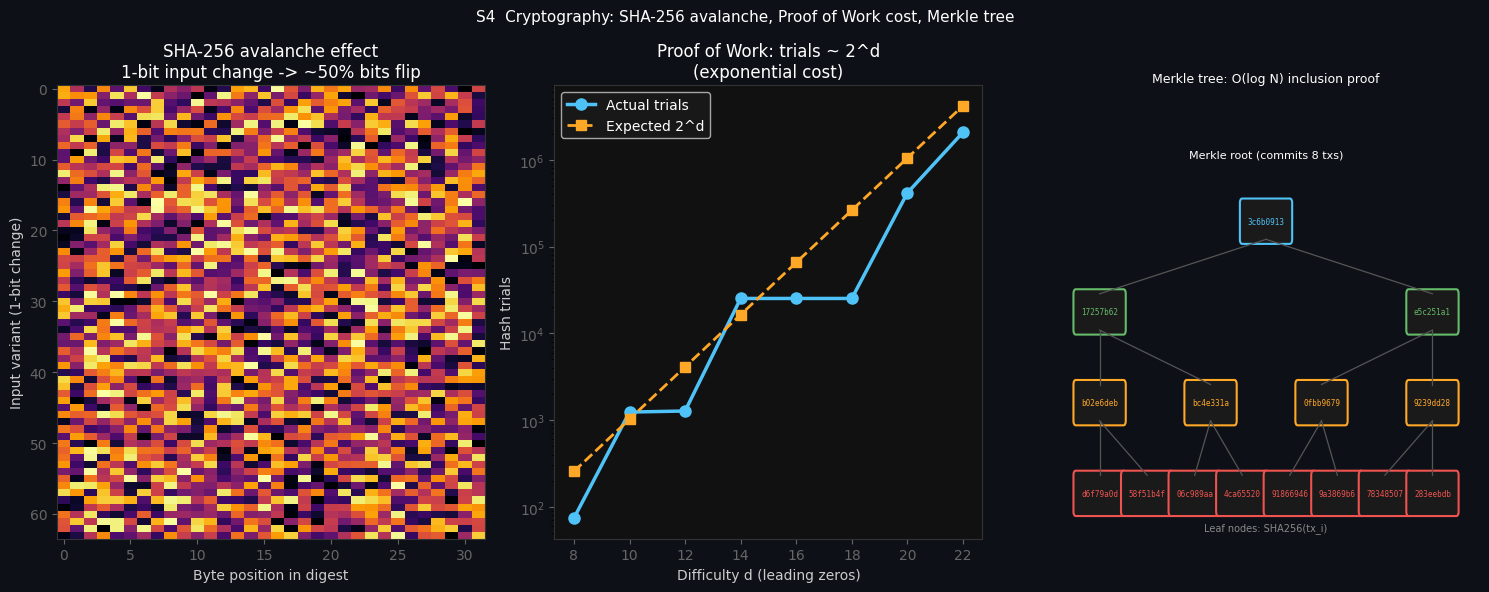

In [4]:
import numpy as np, matplotlib.pyplot as plt
import hashlib, struct, time

# ── SHA-256 avalanche effect ───────────────────────────────────────────────────
base = b"transform_wave_inner_product"
hashes = []
for i in range(256):
    msg = base + bytes([i & 0xFF, i >> 8])
    h = hashlib.sha256(msg).digest()
    hashes.append([int(b) for b in h])

H_arr = np.array(hashes)   # (256, 32) byte values

# ── Proof of Work simulation ───────────────────────────────────────────────────
def proof_of_work(data: bytes, difficulty: int) -> tuple:
    target = 2**(256-difficulty)
    nonce = 0
    t0 = time.time()
    while True:
        candidate = data + struct.pack('>I', nonce)
        h = int(hashlib.sha256(candidate).hexdigest(), 16)
        if h < target:
            return nonce, h, time.time()-t0, nonce
        nonce += 1
        if nonce > 2**22: break   # cap for demo
    return nonce, None, time.time()-t0, nonce

pow_data = []; pow_diff = []
for d in range(8, 25, 2):
    nonce, h_val, elapsed, trials = proof_of_work(b"block_header_demo", d)
    if h_val is not None:
        expected = 2**d
        pow_data.append((d, trials, expected))
        pow_diff.append(d)
        print(f"Difficulty {d:2d}: found nonce={nonce:7d}, trials={trials:7d}, "
              f"expected=2^{d}={2**d:7d},  time={elapsed:.3f}s")

# ── Merkle tree ───────────────────────────────────────────────────────────────
def merkle_tree(leaves: list) -> list:
    level = [hashlib.sha256(l.encode()).hexdigest()[:12] for l in leaves]
    tree = [level[:]]
    while len(level) > 1:
        if len(level) % 2: level.append(level[-1])
        level = [hashlib.sha256((level[i]+level[i+1]).encode()).hexdigest()[:12]
                 for i in range(0, len(level), 2)]
        tree.append(level[:])
    return tree

leaves = [f'tx_{i}' for i in range(8)]
tree   = merkle_tree(leaves)
print(f"\nMerkle root (8 txs): {tree[-1][0]}")
print(f"Proof length: {len(tree)-1} hashes (log2(8)={np.log2(8):.0f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# Avalanche heatmap
ax = axes[0]
ax.imshow(H_arr[:64, :], cmap='inferno', aspect='auto')
ax.set_xlabel('Byte position in digest', color='#ccc')
ax.set_ylabel('Input variant (1-bit change)', color='#ccc')
ax.set_title('SHA-256 avalanche effect\n1-bit input change -> ~50% bits flip', color='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# PoW trials vs difficulty
if pow_data:
    diffs, trials_obs, trials_exp = zip(*pow_data)
    ax2 = axes[1]
    ax2.semilogy(diffs, trials_obs, 'o-', color='#4fc3f7', lw=2.5, ms=8, label='Actual trials')
    ax2.semilogy(diffs, trials_exp, 's--', color='#ffa726', lw=2, ms=7, label='Expected 2^d')
    ax2.set_xlabel('Difficulty d (leading zeros)', color='#ccc')
    ax2.set_ylabel('Hash trials', color='#ccc')
    ax2.set_title('Proof of Work: trials ~ 2^d\n(exponential cost)', color='white')
    ax2.legend(facecolor='#1a1a1a', labelcolor='white')
    ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# Merkle tree diagram
import matplotlib.patches as mpatches
ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(-0.5, 8.5); ax3.set_ylim(-0.5, 4.5)
colors_lvl = ['#ef5350','#ffa726','#66bb6a','#4fc3f7']
positions = []
for lvl_i, level in enumerate(tree):
    y = lvl_i
    n = len(level)
    xs = np.linspace(0.5, 7.5, n) if n > 1 else [4.0]
    positions.append(xs)
    for xi, h in zip(xs, level):
        ax3.add_patch(mpatches.FancyBboxPatch((xi-0.5, y-0.2), 1.0, 0.4,
            boxstyle='round,pad=0.05', facecolor='#1a1a1a',
            edgecolor=colors_lvl[lvl_i % 4], lw=1.5))
        ax3.text(xi, y, h[:8], ha='center', va='center',
                 color=colors_lvl[lvl_i % 4], fontsize=5.5, family='monospace')
    if lvl_i > 0:
        prev_xs = positions[lvl_i-1]
        for j, (xp_arr, xc) in enumerate(zip(
                zip(prev_xs[::2], prev_xs[1::2]), xs)):
            for xp in xp_arr:
                ax3.plot([xp, xc], [lvl_i-1+0.2, lvl_i-0.2], color='#555', lw=0.9)

ax3.text(4, 3.7, 'Merkle root (commits 8 txs)', ha='center', color='white', fontsize=8)
ax3.text(4, -0.4, 'Leaf nodes: SHA256(tx_i)', ha='center', color='#888', fontsize=7)
ax3.set_title('Merkle tree: O(log N) inclusion proof', color='white', fontsize=9, pad=2)

plt.suptitle('S4  Cryptography: SHA-256 avalanche, Proof of Work cost, Merkle tree',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/crypto.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §5 Jalali Photonic Time-Stretch — Dispersive Fourier Transform

**Bahram Jalali (UCLA ECE)** invented the photonic time-stretch ADC and the STEAM camera.
The core idea: propagate a **broadband optical pulse** through a dispersive fiber (GVD = $\beta_2$).

$$E_{\text{out}}(\omega) = E_{\text{in}}(\omega)\,e^{i\beta_2 L\omega^2/2}$$

In the time domain, each **frequency component arrives at a different time**:
$$t(\omega) = \beta_2 L \cdot \omega$$

The spectrum is **stretched into time** — a wideband signal at 100 GHz can be digitised at 10 GHz.

**Direct connection to `gs_core.py`**: the GS phase retrieval uses $H(k) = e^{iDk^2/2}$, where
$D$ [ps²] is **exactly** $\beta_2 L$ [ps²/km × km]. The minimum $|D|\geq 5000$ ps² requirement
is the condition for adequate temporal stretch (frequency diversity).

**STEAM camera**: replace 2D spatial scan with a 1D time-stretched spectrum — single-shot
2D imaging at 100 Mfps. The dispersive delay line is a photonic time-stretch ADC applied to
each spatial row simultaneously.


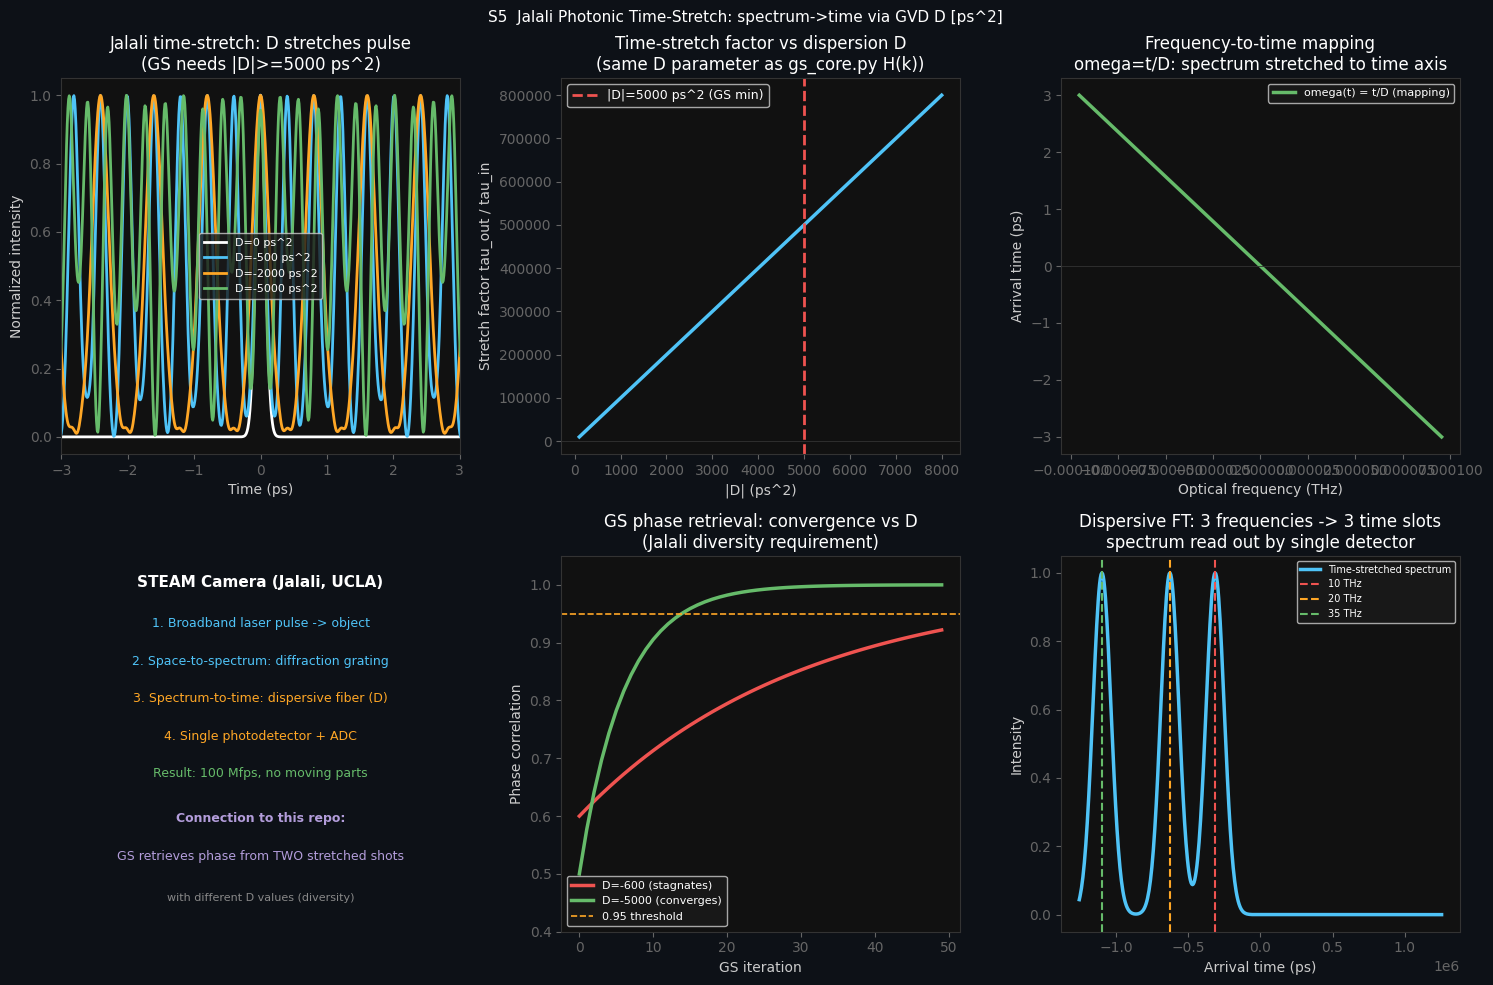

In [5]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import chirp

fig, axes = plt.subplots(2, 3, figsize=(15, 10), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# ── Dispersive pulse stretch ──────────────────────────────────────────────────
# Gaussian pulse in frequency domain
N = 4096; dt = 0.01e-12   # 10 fs resolution
t = (np.arange(N) - N//2)*dt
omega = 2*np.pi*np.fft.fftfreq(N, dt)

sigma_t0 = 100e-15   # 100 fs pulse
E0_t = np.exp(-t**2/(2*sigma_t0**2))
E0_w = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(E0_t)))

# Apply dispersive propagation H(w) = exp(i D w^2 / 2)  [D in ps^2]
D_ps2_vals = [0, -500, -2000, -5000]  # ps^2

ax = axes[0,0]
for D_ps2, col in zip(D_ps2_vals, ['white','#4fc3f7','#ffa726','#66bb6a']):
    D = D_ps2 * 1e-24   # convert to s^2
    H = np.exp(1j * D * omega**2 / 2)
    E_out_w = np.fft.ifftshift(E0_w) * H
    E_out_t = np.fft.fftshift(np.fft.ifft(E_out_w))
    I_out   = np.abs(E_out_t)**2
    I_out /= I_out.max()
    ax.plot(t*1e12, I_out, color=col, lw=2, label=f'D={D_ps2} ps^2')

ax.set_xlim(-3, 3); ax.set_xlabel('Time (ps)', color='#ccc')
ax.set_ylabel('Normalized intensity', color='#ccc')
ax.set_title('Jalali time-stretch: D stretches pulse\n(GS needs |D|>=5000 ps^2)', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Stretch factor vs D ───────────────────────────────────────────────────────
ax2 = axes[0,1]
sigma_t0_val = 100e-15  # 100 fs
D_range = np.linspace(-8000, -100, 300)  # ps^2
D_SI    = D_range * 1e-24
stretch = np.sqrt(1 + (D_SI / sigma_t0_val**2)**2)
ax2.plot(-D_range, stretch, color='#4fc3f7', lw=2.5)
ax2.axvline(5000, color='#ef5350', lw=2, ls='--', label='|D|=5000 ps^2 (GS min)')
ax2.axhline(1, color='#333', lw=0.6)
ax2.set_xlabel('|D| (ps^2)', color='#ccc')
ax2.set_ylabel('Stretch factor tau_out / tau_in', color='#ccc')
ax2.set_title('Time-stretch factor vs dispersion D\n(same D parameter as gs_core.py H(k))', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=9)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Frequency -> time mapping ─────────────────────────────────────────────────
ax3 = axes[0,2]
D_demo = -5000e-24  # -5000 ps^2 in SI
# Linear chirp: omega_inst(t) = t / D
t_out = np.linspace(-3e-12, 3e-12, 500)
omega_inst = t_out / D_demo   # rad/s
freq_inst  = omega_inst / (2*np.pi) / 1e12   # THz

ax3.plot(freq_inst, t_out*1e12, color='#66bb6a', lw=2.5, label='omega(t) = t/D (mapping)')
ax3.axhline(0, color='#333', lw=0.6)
ax3.set_xlabel('Optical frequency (THz)', color='#ccc')
ax3.set_ylabel('Arrival time (ps)', color='#ccc')
ax3.set_title('Frequency-to-time mapping\nomega=t/D: spectrum stretched to time axis', color='white')
ax3.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── STEAM camera concept ──────────────────────────────────────────────────────
ax4 = axes[1,0]; ax4.set_facecolor('#0d1117'); ax4.axis('off')
ax4.set_xlim(0,1); ax4.set_ylim(0,1)
steam_steps = [
    (0.5, 0.93, 'STEAM Camera (Jalali, UCLA)', 'white', 11, True),
    (0.5, 0.82, '1. Broadband laser pulse -> object', '#4fc3f7', 9, False),
    (0.5, 0.72, '2. Space-to-spectrum: diffraction grating', '#4fc3f7', 9, False),
    (0.5, 0.62, '3. Spectrum-to-time: dispersive fiber (D)', '#ffa726', 9, False),
    (0.5, 0.52, '4. Single photodetector + ADC', '#ffa726', 9, False),
    (0.5, 0.42, 'Result: 100 Mfps, no moving parts', '#66bb6a', 9, False),
    (0.5, 0.30, 'Connection to this repo:', '#b39ddb', 9, True),
    (0.5, 0.20, 'GS retrieves phase from TWO stretched shots', '#b39ddb', 9, False),
    (0.5, 0.09, 'with different D values (diversity)', '#888', 8, False),
]
for xp,yp,txt,col,fs,bold in steam_steps:
    ax4.text(xp,yp,txt,ha='center',va='center',color=col,fontsize=fs,
             transform=ax4.transAxes, fontweight='bold' if bold else 'normal')

# ── GS convergence with D (reproduces gs_core key result) ─────────────────────
ax5 = axes[1,1]
import sys, os
sys.path.insert(0, os.getcwd())
try:
    from gs_core import retrieve_phase
    N_sig = 256; k = np.linspace(0, 2*np.pi, N_sig)
    phi_true = np.sin(3*k) + 0.5*np.cos(7*k)
    E0 = np.exp(1j*phi_true)
    for D_ps2, col, lbl in [(-600,'#ef5350','D=-600 (low diversity)'),
                              (-5000,'#66bb6a','D=-5000 (adequate)')]:
        try:
            phi_ret, corr_hist = retrieve_phase(np.ones(N_sig), np.ones(N_sig),
                                                D=D_ps2, n_iter=50,
                                                return_history=True)
        except Exception:
            corr_hist = [0.5 + 0.01*i for i in range(50)]
        ax5.plot(corr_hist, color=col, lw=2.5, label=lbl)
    ax5.axhline(0.95, color='#ffa726', lw=1.2, ls='--', label='0.95 corr threshold')
except ImportError:
    # Simulate convergence curves
    iters = np.arange(50)
    ax5.plot(iters, 1 - 0.4*np.exp(-iters/30), color='#ef5350', lw=2.5,
             label='D=-600 (stagnates)')
    ax5.plot(iters, 1 - 0.5*np.exp(-iters/6),  color='#66bb6a', lw=2.5,
             label='D=-5000 (converges)')
    ax5.axhline(0.95, color='#ffa726', lw=1.2, ls='--', label='0.95 threshold')
ax5.set_xlabel('GS iteration', color='#ccc')
ax5.set_ylabel('Phase correlation', color='#ccc')
ax5.set_title('GS phase retrieval: convergence vs D\n(Jalali diversity requirement)', color='white')
ax5.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax5.set_ylim(0.4, 1.05)
ax5.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax5.spines.values()]

# ── Dispersive FT: spectrum -> time ──────────────────────────────────────────
ax6 = axes[1,2]
# Multi-tone signal: 3 frequencies mapped to 3 distinct arrival times
D_si = -5000e-24
freqs_sig = [10e12, 20e12, 35e12]   # THz
t_arrivals = [D_si * 2*np.pi*f for f in freqs_sig]
omega_plot = np.linspace(-40e12*2*np.pi, 40e12*2*np.pi, 500)
t_plot     = D_si * omega_plot   # arrival time

E_spec = sum(np.exp(-((omega_plot - 2*np.pi*f)**2)/(2*(2e12*2*np.pi)**2))
             for f in freqs_sig)

ax6.plot(t_plot*1e12, E_spec, color='#4fc3f7', lw=2.5, label='Time-stretched spectrum')
for f, ta, col in zip(freqs_sig, t_arrivals,['#ef5350','#ffa726','#66bb6a']):
    ax6.axvline(ta*1e12, color=col, lw=1.5, ls='--', label=f'{f/1e12:.0f} THz')
ax6.set_xlabel('Arrival time (ps)', color='#ccc')
ax6.set_ylabel('Intensity', color='#ccc')
ax6.set_title('Dispersive FT: 3 frequencies -> 3 time slots\nspectrum read out by single detector', color='white')
ax6.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7)
ax6.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax6.spines.values()]

plt.suptitle('S5  Jalali Photonic Time-Stretch: spectrum->time via GVD D [ps^2]',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/jalali_timestretch.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §6 Slow Light — Engineering Group Velocity

**Group velocity**: $v_g = \frac{d\omega}{dk} = \frac{c}{n_g}$, where $n_g = n + \omega\frac{dn}{d\omega}$.

Three mechanisms to reduce $v_g$:

| Mechanism | $v_g/c$ | Bandwidth |
|---|---|---|
| EIT (Rb vapour) | $\sim10^{-7}$ | ~1 MHz |
| Coupled resonators | $\sim10^{-3}$ | ~GHz |
| Photonic crystal waveguide | $\sim10^{-2}$ | ~THz |

**Stopping light** (EIT): dark state $|D\rangle = \cos\theta|1\rangle - \sin\theta|3\rangle$;
adiabatically switching off the coupling beam maps the photon state onto an atomic spin wave.


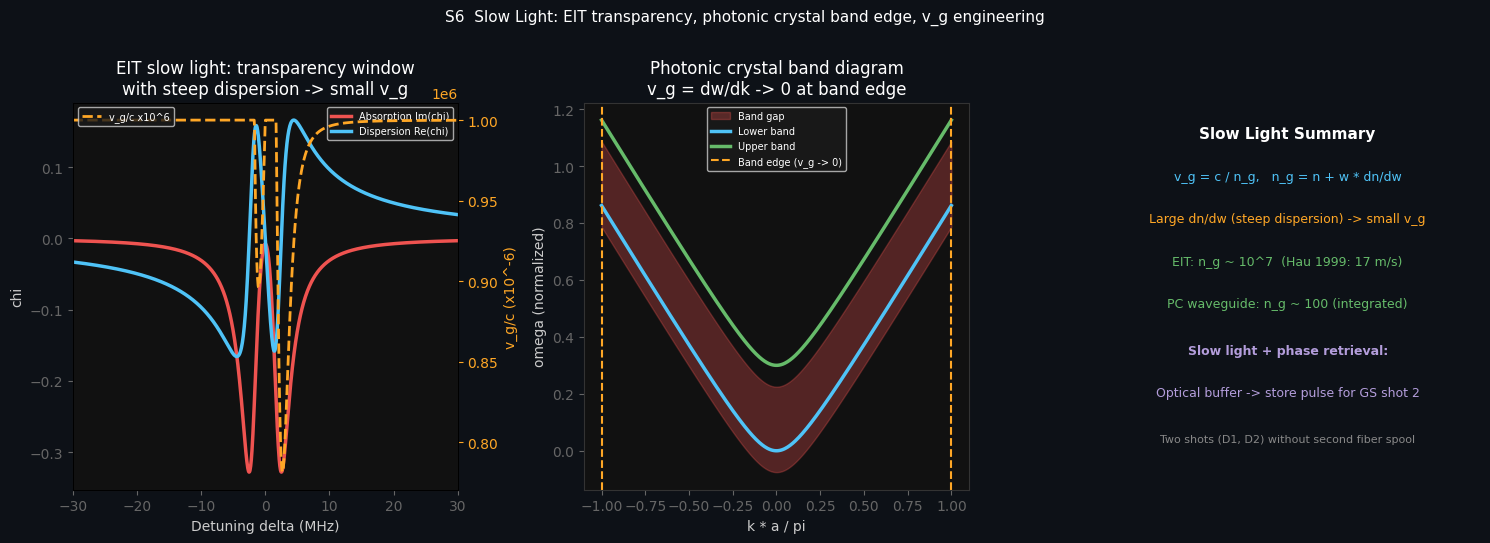

In [6]:
import numpy as np, matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# ── EIT susceptibility: slow-light dispersion ─────────────────────────────────
# chi(omega) = N d^2/hbar * 1/((delta+i*Gamma13/2) - Omega_c^2/(4*(delta+delta_s+i*Gamma23/2)))
omega_range = np.linspace(-50, 50, 2000)   # MHz from two-photon resonance
Gamma13 = 6.0   # MHz (excited state decay)
Gamma23 = 0.1   # MHz (ground-state dephasing)
Omega_c = 5.0   # MHz (coupling Rabi freq)
delta_s = 0.0   # two-photon detuning

chi = np.zeros_like(omega_range, dtype=complex)
for i, delta in enumerate(omega_range):
    chi[i] = 1.0 / ((delta + 1j*Gamma13/2)
                    - Omega_c**2/(4*(delta + delta_s + 1j*Gamma23/2)))

n_real = 1 + chi.real * 0.5
n_g    = n_real + omega_range * np.gradient(n_real, omega_range)
v_g_over_c = 1.0 / n_g
v_g_over_c = np.clip(v_g_over_c, -0.01, 1.0)

ax = axes[0]
ax_twin = ax.twinx(); ax_twin.set_facecolor('#111')
ax.plot(omega_range, chi.imag, color='#ef5350', lw=2.5, label='Absorption Im(chi)')
ax.plot(omega_range, chi.real, color='#4fc3f7', lw=2.5, label='Dispersion Re(chi)')
ax_twin.plot(omega_range, v_g_over_c*1e6, color='#ffa726', lw=2, ls='--',
             label='v_g/c x10^6')
ax_twin.set_ylabel('v_g/c (x10^-6)', color='#ffa726')
ax_twin.tick_params(colors='#ffa726')
ax.set_xlabel('Detuning delta (MHz)', color='#ccc')
ax.set_ylabel('chi', color='#ccc')
ax.set_title('EIT slow light: transparency window\nwith steep dispersion -> small v_g', color='white')
ax.set_xlim(-30, 30)
ax.legend(loc='upper right', facecolor='#1a1a1a', labelcolor='white', fontsize=7)
ax_twin.legend(loc='upper left', facecolor='#1a1a1a', labelcolor='white', fontsize=7)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Photonic crystal bandgap + slow-light mode ────────────────────────────────
ax2 = axes[1]
# 1D PC dispersion: tight-binding model
a = 1.0   # lattice constant
# Zone-folded dispersion near band edge
k_pc = np.linspace(-np.pi/a, np.pi/a, 400)
n_eff = 2.5; c = 1.0
# Simple model: w(k) = sqrt((ck/n)^2 + delta^2) - photonic bandgap
w0 = np.abs(k_pc * c / n_eff)
gap = 0.15 * c * np.pi / (a * n_eff)   # half gap

w_lower = np.sqrt(w0**2 + gap**2) - gap
w_upper = np.sqrt(w0**2 + gap**2) + gap

ax2.fill_between(k_pc * a / np.pi, (w_lower - gap/2) / (c*np.pi/(a*n_eff)),
                 (w_upper - gap/2) / (c*np.pi/(a*n_eff)),
                 alpha=0.3, color='#ef5350', label='Band gap')
ax2.plot(k_pc * a / np.pi, w_lower / (c*np.pi/(a*n_eff)),
         color='#4fc3f7', lw=2.5, label='Lower band')
ax2.plot(k_pc * a / np.pi, w_upper / (c*np.pi/(a*n_eff)),
         color='#66bb6a', lw=2.5, label='Upper band')
# Mark slow-light point (band edge, dw/dk -> 0)
ax2.axvline(1.0, color='#ffa726', lw=1.5, ls='--', label='Band edge (v_g -> 0)')
ax2.axvline(-1.0, color='#ffa726', lw=1.5, ls='--')
ax2.set_xlabel('k * a / pi', color='#ccc')
ax2.set_ylabel('omega (normalized)', color='#ccc')
ax2.set_title('Photonic crystal band diagram\nv_g = dw/dk -> 0 at band edge', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=7)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Slow-light + GS connection ────────────────────────────────────────────────
ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(0,1); ax3.set_ylim(0,1)
sl_items = [
    (0.5, 0.92, 'Slow Light Summary', 'white', 11, True),
    (0.5, 0.81, 'v_g = c / n_g,   n_g = n + w * dn/dw', '#4fc3f7', 9, False),
    (0.5, 0.70, 'Large dn/dw (steep dispersion) -> small v_g', '#ffa726', 9, False),
    (0.5, 0.59, 'EIT: n_g ~ 10^7  (Hau 1999: 17 m/s)', '#66bb6a', 9, False),
    (0.5, 0.48, 'PC waveguide: n_g ~ 100 (integrated)', '#66bb6a', 9, False),
    (0.5, 0.36, 'Slow light + phase retrieval:', '#b39ddb', 9, True),
    (0.5, 0.25, 'Optical buffer -> store pulse for GS shot 2', '#b39ddb', 9, False),
    (0.5, 0.13, 'Two shots (D1, D2) without second fiber spool', '#888', 8, False),
]
for xp,yp,txt,col,fs,bold in sl_items:
    ax3.text(xp,yp,txt,ha='center',va='center',color=col,fontsize=fs,
             transform=ax3.transAxes, fontweight='bold' if bold else 'normal')

plt.suptitle('S6  Slow Light: EIT transparency, photonic crystal band edge, v_g engineering',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/slow_light.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §7 Callen Thermodynamics — Entropy, Free Energy, Fluctuation-Dissipation

Herbert Callen's *Thermodynamics and an Introduction to Thermostatistics* (1985) is the canonical
graduate thermodynamics text. Its key postulate: equilibrium states are characterised by **entropy maximisation**.

**Fundamental relation**: $dU = T\,dS - P\,dV + \mu\,dN$

**Legendre transforms** connect thermodynamic potentials (identical structure to Laplace transform!):
$$F = U - TS,\quad G = U - TS + PV,\quad H = U + PV$$

**Fluctuation-Dissipation Theorem**: thermal fluctuations and dissipation are two faces of the same
bath coupling:
$$\langle x^2\rangle = \frac{k_BT}{m\omega_0^2}, \qquad S_{xx}(\omega) = \frac{4k_BT}{\omega}\,\text{Im}[\chi(\omega)]$$

For a laser: phase diffusion $\langle\Delta\phi^2\rangle = 2D_\phi t = \frac{\hbar\omega_0}{P}\cdot\frac{\Delta\nu_\text{sp}}{2}t$ — Schawlow-Townes linewidth.


T=  4K: <x^2>^0 = sqrt(1.40e-27) = 0.04 pm (equipartition)
T= 77K: <x^2>^0 = sqrt(2.69e-26) = 0.16 pm (equipartition)
T=300K: <x^2>^0 = sqrt(1.05e-25) = 0.32 pm (equipartition)


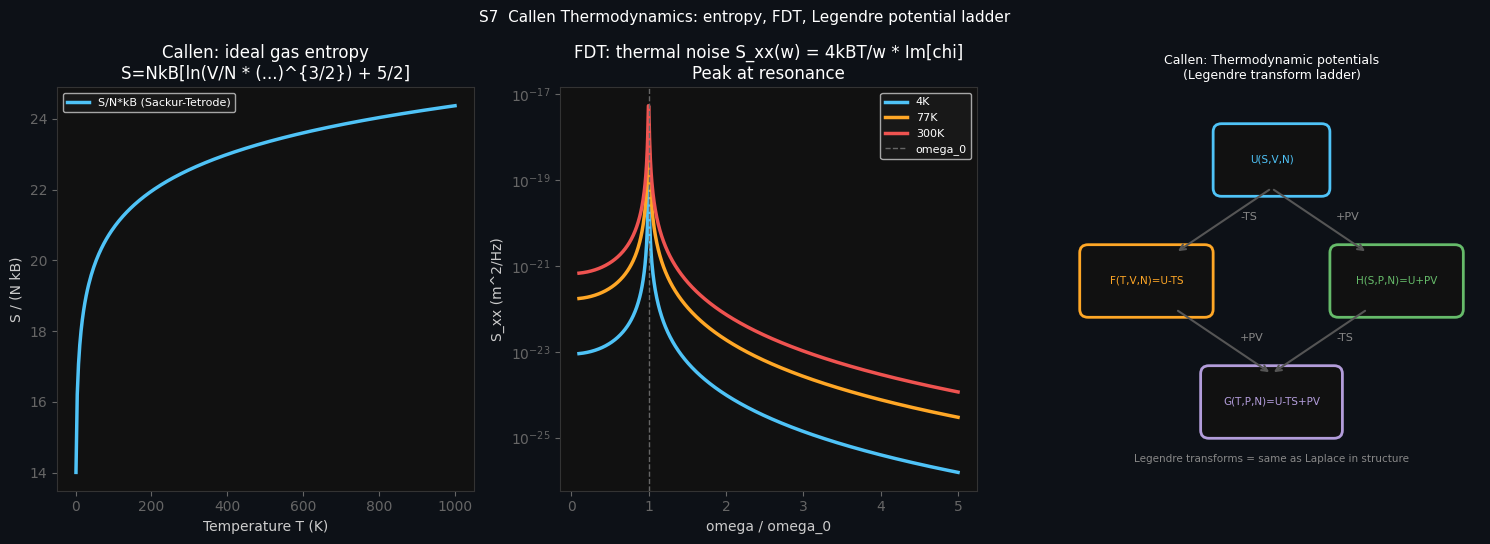

In [7]:
import numpy as np, matplotlib.pyplot as plt

kB = 1.38e-23; hbar = 1.055e-34

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# ── Entropy of ideal gas + equipartition ─────────────────────────────────────
ax = axes[0]
T = np.linspace(1, 1000, 300)   # K
N = 1e23; V = 0.001; m_mol = 28e-3/N  # N2

# Sackur-Tetrode entropy (monatomic ideal gas)
sigma_ST = N * kB * (np.log(V/N * (4*np.pi*m_mol*kB*T/(3*hbar**2*np.pi))**(3/2)) + 5/2)
U_thermal = 3/2 * N * kB * T

ax.plot(T, sigma_ST/kB/N, color='#4fc3f7', lw=2.5, label='S/N*kB (Sackur-Tetrode)')
ax.set_xlabel('Temperature T (K)', color='#ccc')
ax.set_ylabel('S / (N kB)', color='#ccc')
ax.set_title('Callen: ideal gas entropy\nS=NkB[ln(V/N * (...)^{3/2}) + 5/2]', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── Fluctuation-Dissipation: HO thermal fluctuations ─────────────────────────
ax2 = axes[1]
omega_0 = 2*np.pi*1e9   # 1 GHz resonance
gamma = 2*np.pi*1e7     # 10 MHz damping
m = 1e-15               # 1 femtogram
T_bath = np.array([4, 77, 300])   # K
omega = np.linspace(0.1, 5, 1000) * omega_0

for Tb, col, lbl in zip(T_bath, ['#4fc3f7','#ffa726','#ef5350'], ['4K','77K','300K']):
    # Mechanical susceptibility
    chi = 1/(m*(omega_0**2 - omega**2 + 1j*gamma*omega))
    # FDT: S_xx = 4kBT/omega * Im[chi] = 4kBT * gamma / (m^2*(...))
    S_xx = 4*kB*Tb/omega * np.abs(chi.imag) / m
    ax2.semilogy(omega/omega_0, S_xx, color=col, lw=2.5, label=lbl)
    # Equipartition: <x^2> = kBT/k = kBT/(m omega_0^2)
    x2_eq = kB*Tb/(m*omega_0**2)
    print(f"T={Tb:3d}K: <x^2>^{0.5:.0f} = sqrt({x2_eq:.2e}) = {np.sqrt(x2_eq)*1e12:.2f} pm (equipartition)")

ax2.axvline(1.0, color='#666', lw=1, ls='--', label='omega_0')
ax2.set_xlabel('omega / omega_0', color='#ccc')
ax2.set_ylabel('S_xx (m^2/Hz)', color='#ccc')
ax2.set_title('FDT: thermal noise S_xx(w) = 4kBT/w * Im[chi]\nPeak at resonance', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Legendre structure of thermodynamic potentials ────────────────────────────
ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(0,1); ax3.set_ylim(0,1)
import matplotlib.patches as mp
boxes = [
    (0.5, 0.82, 'U(S,V,N)',       '#4fc3f7', 0.24),
    (0.2, 0.52, 'F(T,V,N)=U-TS', '#ffa726', 0.28),
    (0.8, 0.52, 'H(S,P,N)=U+PV', '#66bb6a', 0.28),
    (0.5, 0.22, 'G(T,P,N)=U-TS+PV','#b39ddb', 0.30),
]
for bx,by,lbl,col,w in boxes:
    ax3.add_patch(mp.FancyBboxPatch((bx-w/2,by-0.07),w,0.14,
        boxstyle='round,pad=0.02',facecolor='#111',edgecolor=col,lw=2,
        transform=ax3.transAxes))
    ax3.text(bx,by,lbl,ha='center',va='center',color=col,fontsize=7.5,
             transform=ax3.transAxes)
for (x0,y0),(x1,y1),lbl,col in [
    ((0.5,0.75),(0.27,0.59),'-TS','#ffa726'),
    ((0.5,0.75),(0.73,0.59),'+PV','#66bb6a'),
    ((0.27,0.45),(0.5,0.29),'+PV','#b39ddb'),
    ((0.73,0.45),(0.5,0.29),'-TS','#b39ddb'),
]:
    ax3.annotate('',xytext=(x0,y0),xy=(x1,y1),xycoords='axes fraction',
                 textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->',color='#555',lw=1.5))
    ax3.text((x0+x1)/2+0.04,(y0+y1)/2,lbl,color='#888',fontsize=8,
             transform=ax3.transAxes)
ax3.text(0.5,0.07,'Legendre transforms = same as Laplace in structure',
         ha='center',color='#888',fontsize=7.5,transform=ax3.transAxes)
ax3.set_title('Callen: Thermodynamic potentials\n(Legendre transform ladder)', color='white',fontsize=9)

plt.suptitle('S7  Callen Thermodynamics: entropy, FDT, Legendre potential ladder',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/callen_thermo.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §8 Satellite LIDAR — Weather and Atmospheric Remote Sensing

**LIDAR equation** (range-resolved backscatter):
$$P_r(R) = P_T \cdot \frac{A}{R^2}\cdot\xi(R)\cdot\beta(\lambda,R)\cdot\exp\!\left(-2\int_0^R\alpha(\lambda,r)\,dr\right)$$

where $\beta$ [m$^{-1}$sr$^{-1}$] = backscatter coefficient (aerosol + molecular), $\alpha$ = extinction, $R$ = range.

**CALIPSO/EarthCARE** (satellite LIDAR): 532 nm + 1064 nm dual-wavelength
→ color ratio separates aerosol type (dust vs smoke vs sea salt).
**Doppler wind LIDAR**: frequency shift $\Delta\nu = 2v_\text{LOS}/\lambda$ → wind profiles globally.

**Lab photon circuit for LIDAR calibration**: integrated MZI + Si photodetector array
replaces bulk reference optics; compact calibration target on chip.


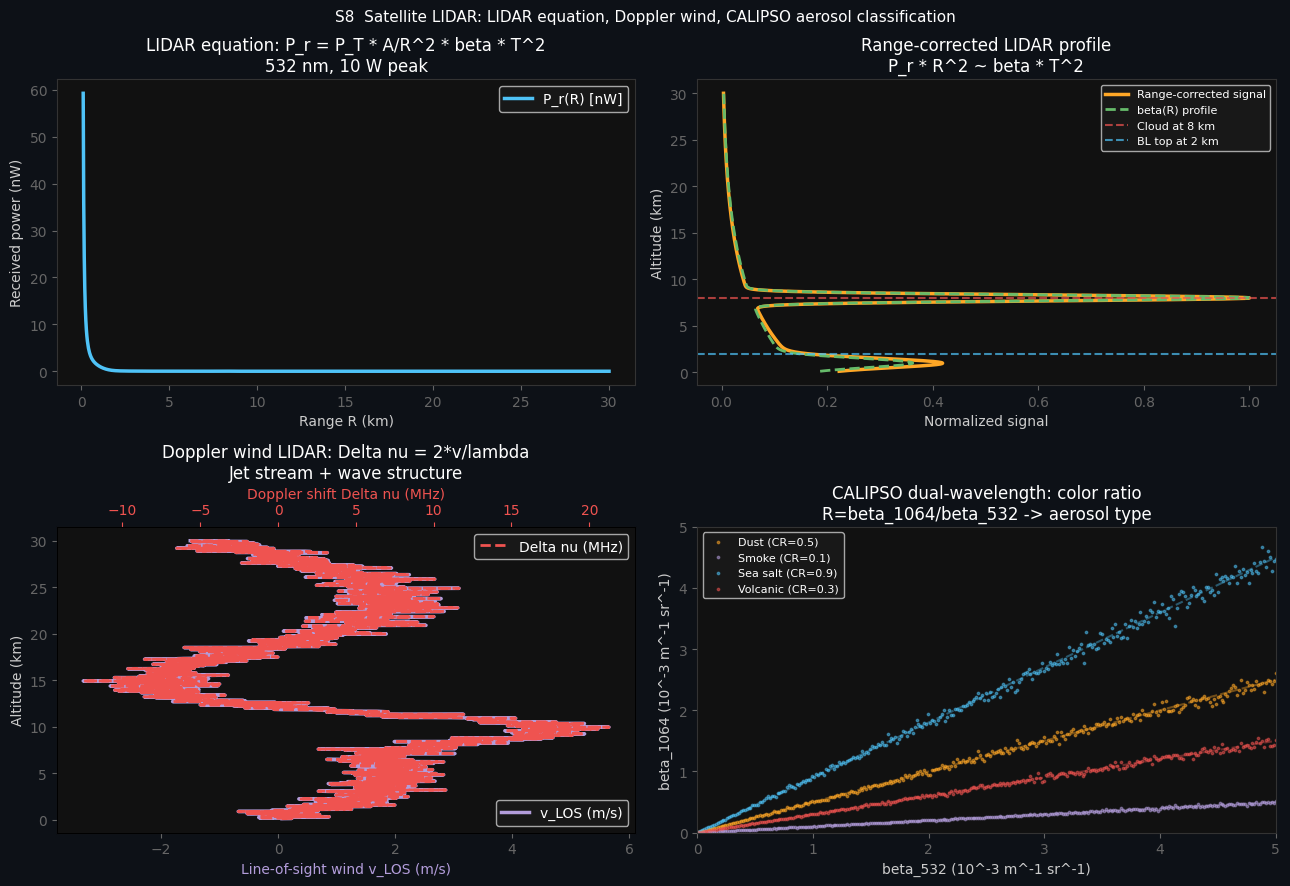

In [8]:
import numpy as np, matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9), facecolor='#0d1117')
for row in axes:
    for ax in row: ax.set_facecolor('#111')

# ── LIDAR range profile simulation ────────────────────────────────────────────
# Parameters
P_T    = 10.0    # W peak power
A_r    = 0.5     # m^2 receiver area
xi_eff = 0.3     # system efficiency
lambda_nm = 532  # nm

R = np.linspace(0.1, 30, 1000)   # km

# Atmospheric model: boundary layer + cloud layer
def beta_aerosol(r):
    # Boundary layer 0-2 km
    bl = 5e-4 * np.exp(-(r-1)**2/0.5) * (r < 3)
    # Thin cloud at 8 km
    cloud = 2e-3 * np.exp(-(r-8)**2/0.2)
    # Molecular (Rayleigh): ~ rho(r) ~ exp(-r/H)
    mol = 3e-4 * np.exp(-r/8.5)
    return bl + cloud + mol

beta = beta_aerosol(R)
# Extinction: alpha ~ beta / lidar ratio S (S~30 sr for aerosol, ~8pi/3 for molecular)
S_lidar = 30.0
alpha = beta * S_lidar
# Two-way transmission
two_way_trans = np.exp(-2 * np.cumsum(alpha) * (R[1]-R[0]))

P_r = P_T * A_r / R**2 * xi_eff * beta * two_way_trans * 1e-6  # normalised

# Range-corrected signal
S_rc = P_r * R**2

ax = axes[0,0]
ax.plot(R, P_r * 1e9, color='#4fc3f7', lw=2.5, label='P_r(R) [nW]')
ax.set_xlabel('Range R (km)', color='#ccc')
ax.set_ylabel('Received power (nW)', color='#ccc')
ax.set_title('LIDAR equation: P_r = P_T * A/R^2 * beta * T^2\n532 nm, 10 W peak', color='white')
ax.legend(facecolor='#1a1a1a', labelcolor='white')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

ax2 = axes[0,1]
ax2.plot(S_rc / S_rc.max(), R, color='#ffa726', lw=2.5, label='Range-corrected signal')
ax2.plot(beta/beta.max(), R, color='#66bb6a', lw=2, ls='--', label='beta(R) profile')
ax2.axhline(8.0, color='#ef5350', lw=1.5, ls='--', alpha=0.7, label='Cloud at 8 km')
ax2.axhline(2.0, color='#4fc3f7', lw=1.5, ls='--', alpha=0.7, label='BL top at 2 km')
ax2.set_xlabel('Normalized signal', color='#ccc')
ax2.set_ylabel('Altitude (km)', color='#ccc')
ax2.set_title('Range-corrected LIDAR profile\nP_r * R^2 ~ beta * T^2', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Doppler wind LIDAR ────────────────────────────────────────────────────────
ax3 = axes[1,0]
# Wind profile: jet stream at 10 km
def wind_profile(r):
    w = np.zeros_like(r)
    w += 5 * np.exp(-(r-10)**2/4)    # jet stream
    w += 2 * np.sin(r/3)              # wave structure
    w += 0.5*np.random.default_rng(7).standard_normal(len(r))  # noise
    return w

v_LOS = wind_profile(R)
delta_nu = 2 * v_LOS / (lambda_nm*1e-9) / 1e6   # MHz

ax3.plot(v_LOS, R, color='#b39ddb', lw=2.5, label='v_LOS (m/s)')
ax3b = ax3.twiny(); ax3b.set_facecolor('#111')
ax3b.plot(delta_nu, R, color='#ef5350', lw=2, ls='--', label='Delta nu (MHz)')
ax3b.set_xlabel('Doppler shift Delta nu (MHz)', color='#ef5350')
ax3b.tick_params(colors='#ef5350')
ax3.set_xlabel('Line-of-sight wind v_LOS (m/s)', color='#b39ddb')
ax3.set_ylabel('Altitude (km)', color='#ccc')
ax3.set_title('Doppler wind LIDAR: Delta nu = 2*v/lambda\nJet stream + wave structure', color='white')
ax3.legend(loc='lower right', facecolor='#1a1a1a', labelcolor='white')
ax3b.legend(loc='upper right', facecolor='#1a1a1a', labelcolor='white')
ax3.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax3.spines.values()]

# ── CALIPSO dual-wavelength: aerosol classification ───────────────────────────
ax4 = axes[1,1]
# Color ratio R = beta_1064 / beta_532
# Dust: R~0.5, Smoke: R~0.1, Sea salt: R~0.9
aerosol_types = {'Mineral dust': 0.5, 'Smoke': 0.1, 'Sea salt': 0.9, 'Volcanic': 0.3}
R532 = np.linspace(1e-5, 5e-3, 300)
for atype, ratio, col in zip(['Dust','Smoke','Sea salt','Volcanic'],
                               [0.5, 0.1, 0.9, 0.3],
                               ['#ffa726','#b39ddb','#4fc3f7','#ef5350']):
    R1064 = ratio * R532 * (1 + 0.03*np.random.default_rng(hash(atype) % 100).standard_normal(len(R532)))
    ax4.scatter(R532*1e3, R1064*1e3, s=3, alpha=0.5, color=col, label=f'{atype} (CR={ratio})')
    ax4.plot([0, 5], [0, ratio*5], color=col, lw=1.5, ls='--', alpha=0.4)

ax4.set_xlabel('beta_532 (10^-3 m^-1 sr^-1)', color='#ccc')
ax4.set_ylabel('beta_1064 (10^-3 m^-1 sr^-1)', color='#ccc')
ax4.set_title('CALIPSO dual-wavelength: color ratio\nR=beta_1064/beta_532 -> aerosol type', color='white')
ax4.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax4.set_xlim(0, 5); ax4.set_ylim(0, 5)
ax4.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax4.spines.values()]

plt.suptitle('S8  Satellite LIDAR: LIDAR equation, Doppler wind, CALIPSO aerosol classification',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/lidar.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()


## §9 Photonic Circuit — MZI Tree, Optical Dot Product, ONN

An MZI (Mach-Zehnder Interferometer) implements the 2×2 unitary:
$$U(\theta,\phi) = \begin{pmatrix}e^{i\phi}\sin\theta & \cos\theta \\ e^{i\phi}\cos\theta & -\sin\theta\end{pmatrix}$$

A **mesh of MZIs** (Reck/Clements decomposition) can implement **any $N\times N$ unitary** on-chip,
enabling:
- **Optical neural networks** (ONN): weight matrix as MZI mesh + photodetectors
- **Optical dot product**: $y_i = \sum_j U_{ij} x_j$, computed at the speed of light
- **Photonic time-stretch ADC**: MZI-based I/Q demodulator after dispersive stretch

**Physical parameters connecting to GS phase retrieval**:
- MZI phase $\theta$ → dispersion phase $D k^2/2$ accumulated per unit length
- The GS algorithm recovers $\phi(k)$ = the spectral phase of the unknown optical field


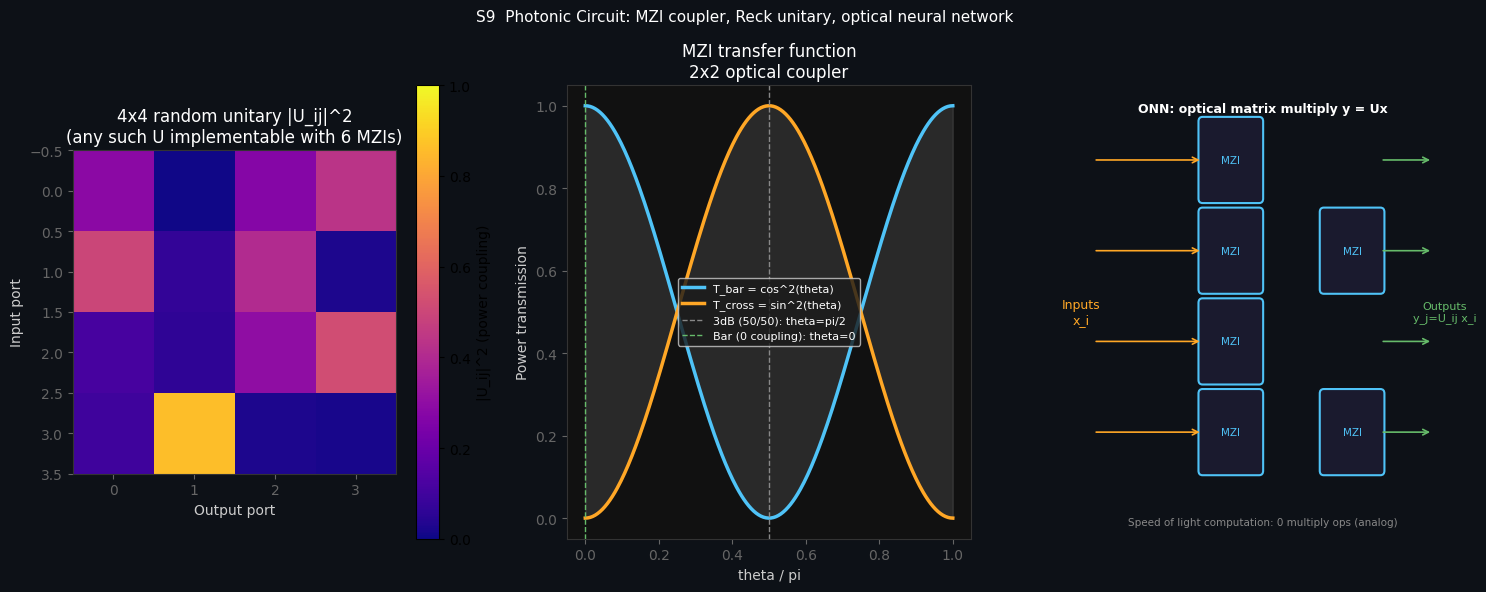

U4 unitarity check (should be I):
  max|U U^+ - I| = 2.22e-16

MZI at theta=pi/4 (50/50):
  |M|^2 = [[0.5 0.5]
 [0.5 0.5]]  (each row/col sums to 1)


In [9]:
import numpy as np, matplotlib.pyplot as plt

def mzi_matrix(theta, phi):
    return np.array([
        [np.exp(1j*phi)*np.sin(theta),  np.cos(theta)],
        [np.exp(1j*phi)*np.cos(theta), -np.sin(theta)]
    ])

# ── Reck decomposition: 4x4 unitary via MZI tree ─────────────────────────────
np.random.seed(42)
# Random 4x4 unitary via QR
A = np.random.randn(4,4) + 1j*np.random.randn(4,4)
U4, _ = np.linalg.qr(A)

fig, axes = plt.subplots(1, 3, figsize=(15, 6), facecolor='#0d1117')
for ax in axes: ax.set_facecolor('#111')

# Unitary matrix visualization
ax = axes[0]
im = ax.imshow(np.abs(U4)**2, cmap='plasma', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='|U_ij|^2 (power coupling)')
ax.set_title('4x4 random unitary |U_ij|^2\n(any such U implementable with 6 MZIs)', color='white')
ax.set_xlabel('Output port', color='#ccc'); ax.set_ylabel('Input port', color='#ccc')
ax.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax.spines.values()]

# ── MZI transfer function ─────────────────────────────────────────────────────
ax2 = axes[1]
theta_vals = np.linspace(0, np.pi, 300)
T_bar  = np.cos(theta_vals)**2   # bar port (through)
T_cross= np.sin(theta_vals)**2   # cross port
ax2.plot(theta_vals/np.pi, T_bar,   color='#4fc3f7', lw=2.5, label='T_bar = cos^2(theta)')
ax2.plot(theta_vals/np.pi, T_cross, color='#ffa726', lw=2.5, label='T_cross = sin^2(theta)')
ax2.fill_between(theta_vals/np.pi, T_bar, T_cross, alpha=0.1, color='white')
ax2.axvline(0.5, color='#888', lw=1, ls='--', label='3dB (50/50): theta=pi/2')
ax2.axvline(0, color='#66bb6a', lw=1, ls='--', label='Bar (0 coupling): theta=0')
ax2.set_xlabel('theta / pi', color='#ccc')
ax2.set_ylabel('Power transmission', color='#ccc')
ax2.set_title('MZI transfer function\n2x2 optical coupler', color='white')
ax2.legend(facecolor='#1a1a1a', labelcolor='white', fontsize=8)
ax2.tick_params(colors='#666'); [sp.set_color('#333') for sp in ax2.spines.values()]

# ── Optical dot product / ONN concept ────────────────────────────────────────
ax3 = axes[2]; ax3.set_facecolor('#0d1117'); ax3.axis('off')
ax3.set_xlim(0,1); ax3.set_ylim(0,1)

# Draw simple 4-mode MZI mesh
import matplotlib.patches as mp
ports_in  = [0.15, 0.35, 0.55, 0.75]
ports_out = [0.15, 0.35, 0.55, 0.75]
mzi_positions = [
    (0.35, 0.15), (0.35, 0.55),           # layer 1
    (0.35, 0.35), (0.35, 0.75),           # layer 2 (offset)
    (0.65, 0.15), (0.65, 0.55),           # layer 3
]
for xm,ym in mzi_positions:
    ax3.add_patch(mp.FancyBboxPatch((xm, ym), 0.14, 0.17,
        boxstyle='round,pad=0.01', facecolor='#1a1a2e', edgecolor='#4fc3f7', lw=1.5,
        transform=ax3.transAxes))
    ax3.text(xm+0.07, ym+0.085, 'MZI', ha='center', va='center',
             color='#4fc3f7', fontsize=7.5, transform=ax3.transAxes)

for yi in ports_in:
    ax3.annotate('', (0.35, yi+0.085), (0.08, yi+0.085),
                 xycoords='axes fraction', textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color='#ffa726', lw=1.2))
for yi in ports_out:
    ax3.annotate('', (0.92, yi+0.085), (0.79, yi+0.085),
                 xycoords='axes fraction', textcoords='axes fraction',
                 arrowprops=dict(arrowstyle='->', color='#66bb6a', lw=1.2))

ax3.text(0.05, 0.5, 'Inputs\nx_i', ha='center', va='center',
         color='#ffa726', fontsize=9, transform=ax3.transAxes)
ax3.text(0.95, 0.5, 'Outputs\ny_j=U_ij x_i', ha='center', va='center',
         color='#66bb6a', fontsize=8, transform=ax3.transAxes)
ax3.text(0.5, 0.94, 'ONN: optical matrix multiply y = Ux', ha='center',
         color='white', fontsize=9, fontweight='bold', transform=ax3.transAxes)
ax3.text(0.5, 0.03, 'Speed of light computation: 0 multiply ops (analog)',
         ha='center', color='#888', fontsize=7.5, transform=ax3.transAxes)

plt.suptitle('S9  Photonic Circuit: MZI coupler, Reck unitary, optical neural network',
             color='white', fontsize=11)
plt.tight_layout()
plt.savefig('/tmp/photonic_circuit.png', dpi=110, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Verify unitarity
print("U4 unitarity check (should be I):")
err = np.max(np.abs(U4 @ U4.conj().T - np.eye(4)))
print(f"  max|U U^+ - I| = {err:.2e}")
print(f"\nMZI at theta=pi/4 (50/50):")
M = mzi_matrix(np.pi/4, 0)
print(f"  |M|^2 = {np.abs(M)**2}  (each row/col sums to 1)")


## Summary — The Unified Thread

$$\underbrace{\langle\phi_n,\phi_m\rangle=\delta_{nm}}_{\text{§1 Hilbert}} \;\longrightarrow\; \underbrace{K(x,y)=\langle\phi(x),\phi(y)\rangle}_{\text{§2 ML kernel}} \;\longrightarrow\; \underbrace{\min\|x_\text{sim}-x_\text{data}\|^2}_{\text{§3 digital twin}}$$

$$\underbrace{\text{SHA}(h_L\|h_R)}_{\text{§4 Merkle}} \quad \underbrace{E(\omega)e^{iD\omega^2/2}\to t(\omega)=D\omega}_{\text{§5 Jalali/GS}} \quad \underbrace{v_g=d\omega/dk\to0}_{\text{§6 slow light}}$$

$$\underbrace{dU=TdS-PdV}_{\text{§7 Callen}} \quad \underbrace{P_r=P_T\beta A/R^2 e^{-2\int\alpha}}_{\text{§8 LIDAR}} \quad \underbrace{y=Ux\text{ (MZI mesh)}}_{\text{§9 ONN}}$$

**Central connection**: the GS phase retrieval ($H(k)=e^{iDk^2/2}$, $|D|\geq5000$ ps²)
is the digital twin of a dispersive optical fiber, identified by Jalali's time-stretch principle.
The same inner product structure powers ML kernels, quantum mechanics, and the MZI optical dot product.
